In [86]:
import pandas as pd
import numpy as np
from pathlib import Path

# Paths
raw_csv_path = Path("data/anes_timeseries_2020_csv_20220210.csv")
clean_csv_path = Path("data/policy_clean.csv")

print(f"Loading {raw_csv_path} ...")
df = pd.read_csv(raw_csv_path)

# Missing codes
MISSING = {-9, -8, -7, -6, -5, -4, -3, -2, -1, 99}
MISSING_THERM = {-9, -8, -7, -6, -5, -4, 998, 999}

def get_first(cols, exclude=MISSING):
    """Return first existing column in df (with missing codes -> NaN), else all-NaN series."""
    for c in cols:
        if c in df.columns:
            return df[c].replace(exclude, np.nan)
    return pd.Series(np.nan, index=df.index)

# Build policy columns with succinct names (<= 15 chars), except the three specified to remain as-is
policy = {}

# Keep these names exactly as requested
policy["ideology_7pt"] = get_first(["V201200"])
policy["ideology_3pt_signed"] = policy["ideology_7pt"].map({1: 1, 2: 1, 3: 1, 4: 0, 5: -1, 6: -1, 7: -1})
policy["party_id_signed"] = get_first(["V201228"]).map({1: -1, 2: 1, 3: 0, 5: 0, 0: 0})

# Immigration / rights / institutions
policy["imm_unauth"]   = get_first(["V201417"])        
policy["birthright"]   = get_first(["V201420x"])
policy["paid_leave"]   = get_first(["V201405x"])
policy["trump_corr"]   = get_first(["V201382x"])
policy["journ_access"] = get_first(["V201375x"])

# Guns / crime / courts
policy["gun_bkg_chk"]  = get_first(["V202341x"])
policy["illeg_child"]  = get_first(["V201423x"])
policy["death_pen"]    = get_first(["V201345x"])
policy["abortion"]     = get_first(["V201336"], exclude={-9, -8, 5})
policy["scotus_abort"] = get_first(["V201342x"])
policy["ar_ban"]       = get_first(["V202344x"])

# Elections / economy
policy["econ_now"]     = get_first(["V201324"])
policy["voter_id"]     = get_first(["V201359x"])
policy["felon_vote"]   = get_first(["V201362x"])

# Health / education / spending
policy["vax_school"]   = get_first(["V202331x"])
policy["spend_border"] = get_first(["V201308x"])
policy["spend_welfare"]= get_first(["V201314x"])        
policy["spend_poor"]   = get_first(["V201320x"])
policy["spend_school"] = get_first(["V201305x"])

# Governance / social issues
policy["checks_power"] = get_first(["V201367"])
policy["border_wall"]  = get_first(["V201426x"])
policy["trans_bath"]   = get_first(["V201411x"])
policy["police_force"] = get_first(["V202351"])
policy["assist_black"] = get_first(["V201258"])
policy["job_guar"]     = get_first(["V201255"])
policy["govt_health"]  = get_first(["V201252"])
policy["obamacare"]    = get_first(["V202328x"])

# Spending / unrest / climate / foreign
policy["svc_spend"]    = get_first(["V201246"])
policy["def_spend"]    = get_first(["V201249"])
policy["urban_unrest"] = get_first(["V201429"])
policy["clim_imp"]     = get_first(["V202333"])
policy["rus_interf"]   = get_first(["V201428"])

# Feeling thermometers
policy["ft_trans"]     = get_first(["V202172"], exclude=MISSING_THERM)
policy["ft_union"]     = get_first(["V202162"], exclude=MISSING_THERM)
policy["ft_fem"]       = get_first(["V202160"], exclude=MISSING_THERM)
policy["ft_sci"]       = get_first(["V202173"], exclude=MISSING_THERM)
policy["ft_police"]    = get_first(["V202171"], exclude=MISSING_THERM)

# Environment / guns / military
policy["env_bus"]      = get_first(["V201262"])        
policy["ghg_emiss"]    = get_first(["V202336x"])
policy["gun_imp"]      = get_first(["V202338"])
policy["mil_force"]    = get_first(["V201350"])

# Assemble clean DataFrame
clean = pd.DataFrame(policy)

# Diagnostics
missing_in_file = [k for k, s in policy.items() if s.isna().all()]
if missing_in_file:
    print("Warning: missing raw columns for:", missing_in_file)

too_long = [c for c in clean.columns if c not in {"party_id_signed", "ideology_7pt", "ideology_3pt_signed"} and len(c) > 15]
if too_long:
    raise ValueError(f"These column names exceed 15 characters: {too_long}")

non_null_counts = clean.notna().sum().sort_values(ascending=False)
print("Non-null counts per column:\n", non_null_counts)

clean.to_csv(clean_csv_path, index=False)
print(f"Saved cleaned policy dataset to {clean_csv_path}")


Loading data/anes_timeseries_2020_csv_20220210.csv ...


/scratch/local/jobs/44131329/ipykernel_1196290/359386984.py:10: DtypeWarning: Columns (15,17,18,19,21,22,23,25,26,27,29,30,31,33,34,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(raw_csv_path)


Non-null counts per column:
 econ_now               8259
voter_id               8256
felon_vote             8251
spend_school           8247
checks_power           8243
paid_leave             8242
border_wall            8240
party_id_signed        8231
spend_border           8227
spend_poor             8225
birthright             8225
mil_force              8222
journ_access           8214
spend_welfare          8213
scotus_abort           8208
imm_unauth             8197
trump_corr             8195
rus_interf             8155
illeg_child            8131
death_pen              8113
trans_bath             7967
abortion               7900
urban_unrest           7713
assist_black           7403
ft_police              7388
gun_bkg_chk            7387
vax_school             7384
clim_imp               7383
obamacare              7382
ar_ban                 7381
gun_imp                7378
ft_sci                 7367
ghg_emiss              7364
police_force           7355
govt_health        

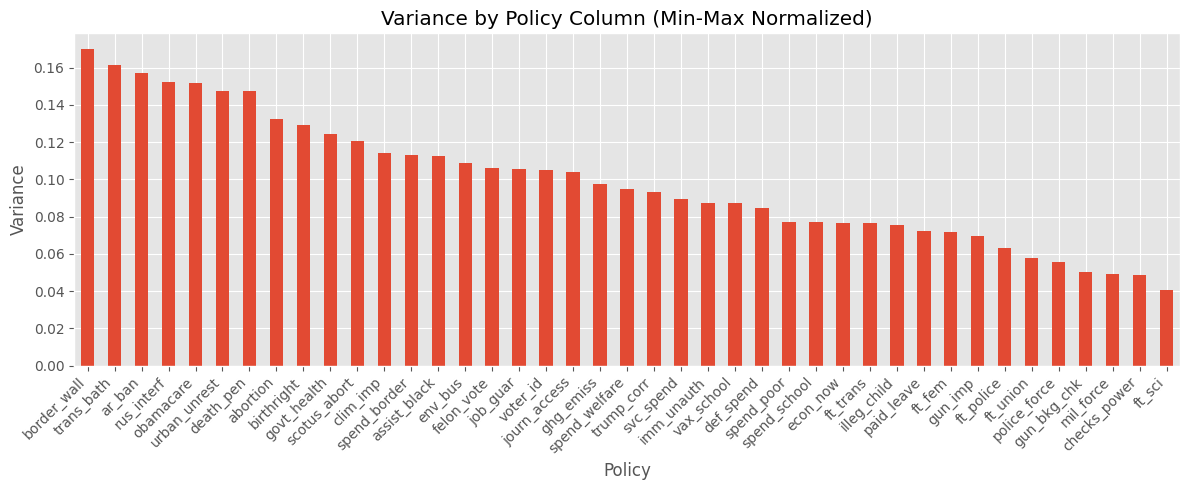

In [87]:
import matplotlib.pyplot as plt

# Load cleaned policy data
clean = pd.read_csv("data/policy_clean.csv")

# Define columns to exclude from normalization (ideology and partisanship)
exclude_cols = ['party_id_signed', 'ideology_7pt', 'ideology_3pt_signed']

# Get policy columns (exclude ideology/partisan columns)
policy_cols = [col for col in clean.columns if col not in exclude_cols]

# Min-max normalize policy columns only
col_min = clean[policy_cols].min(skipna=True)
col_max = clean[policy_cols].max(skipna=True)
col_range = col_max - col_min
safe_range = col_range.replace(0, np.nan)

clean_normalized = clean.copy()
clean_normalized[policy_cols] = (clean[policy_cols] - col_min) / safe_range

# Calculate variance for each policy
variance = {col: clean_normalized[col].var(skipna=True) for col in policy_cols}
variance_sorted = dict(sorted(variance.items(), key=lambda x: x[1], reverse=True))

# Plot 1: Variance
plt.figure(figsize=(12, 5))
pd.Series(variance_sorted).plot(kind='bar')
plt.title('Variance by Policy Column (Min-Max Normalized)')
plt.ylabel('Variance')
plt.xlabel('Policy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

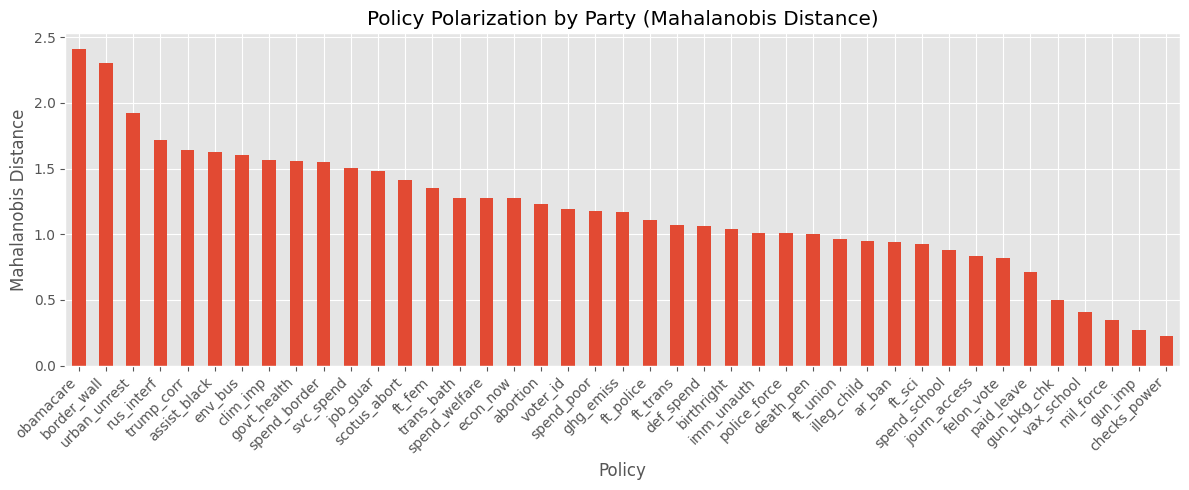


Top 10 Most Polarized Policies (Mahalanobis):
1. obamacare: 2.4081
2. border_wall: 2.3030
3. urban_unrest: 1.9199
4. rus_interf: 1.7166
5. trump_corr: 1.6373
6. assist_black: 1.6231
7. env_bus: 1.5994
8. clim_imp: 1.5654
9. govt_health: 1.5561
10. spend_border: 1.5508


In [88]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Calculate polarization by party for each policy (using Mahalanobis Distance)
polarization = {}

for col in policy_cols:
    # Get data for each party (drop NaNs to ensure valid variance calc)
    dem_data = clean_normalized[col][clean['party_id_signed'] == -1].dropna()
    rep_data = clean_normalized[col][clean['party_id_signed'] == 1].dropna()
    
    # We need at least 2 points to calculate variance
    if len(dem_data) < 2 or len(rep_data) < 2:
        polarization[col] = 0.0
        continue
    
    # 1. Calculate Means
    mu_d = dem_data.mean()
    mu_r = rep_data.mean()
    
    # 2. Calculate Pooled Variance (1D equivalent of Pooled Covariance Matrix)
    var_d = dem_data.var()
    var_r = rep_data.var()
    
    # Average the variances (consistent with your LLM pipeline's `(cov_d + cov_r) / 2`)
    pool_var = (var_d + var_r) / 2
    
    # Regularization to prevent division by zero (same as your `+ np.eye * 1e-6`)
    pool_var += 1e-6 
    
    # 3. Calculate Mahalanobis Distance
    # Formula for 1D: |Mean_Diff| / sqrt(Pooled_Variance)
    polarization[col] = abs(mu_r - mu_d) / np.sqrt(pool_var)

# Sort polarization for plotting
polarization_sorted = dict(sorted(polarization.items(), key=lambda x: x[1], reverse=True))

# Plot 2: Polarization
plt.figure(figsize=(12, 5))
pd.Series(polarization_sorted).plot(kind='bar')
plt.title('Policy Polarization by Party (Mahalanobis Distance)')
plt.ylabel('Mahalanobis Distance')
plt.xlabel('Policy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Polarized Policies (Mahalanobis):")
for i, (policy, value) in enumerate(list(polarization_sorted.items())[:10], 1):
    print(f"{i}. {policy}: {value:.4f}")

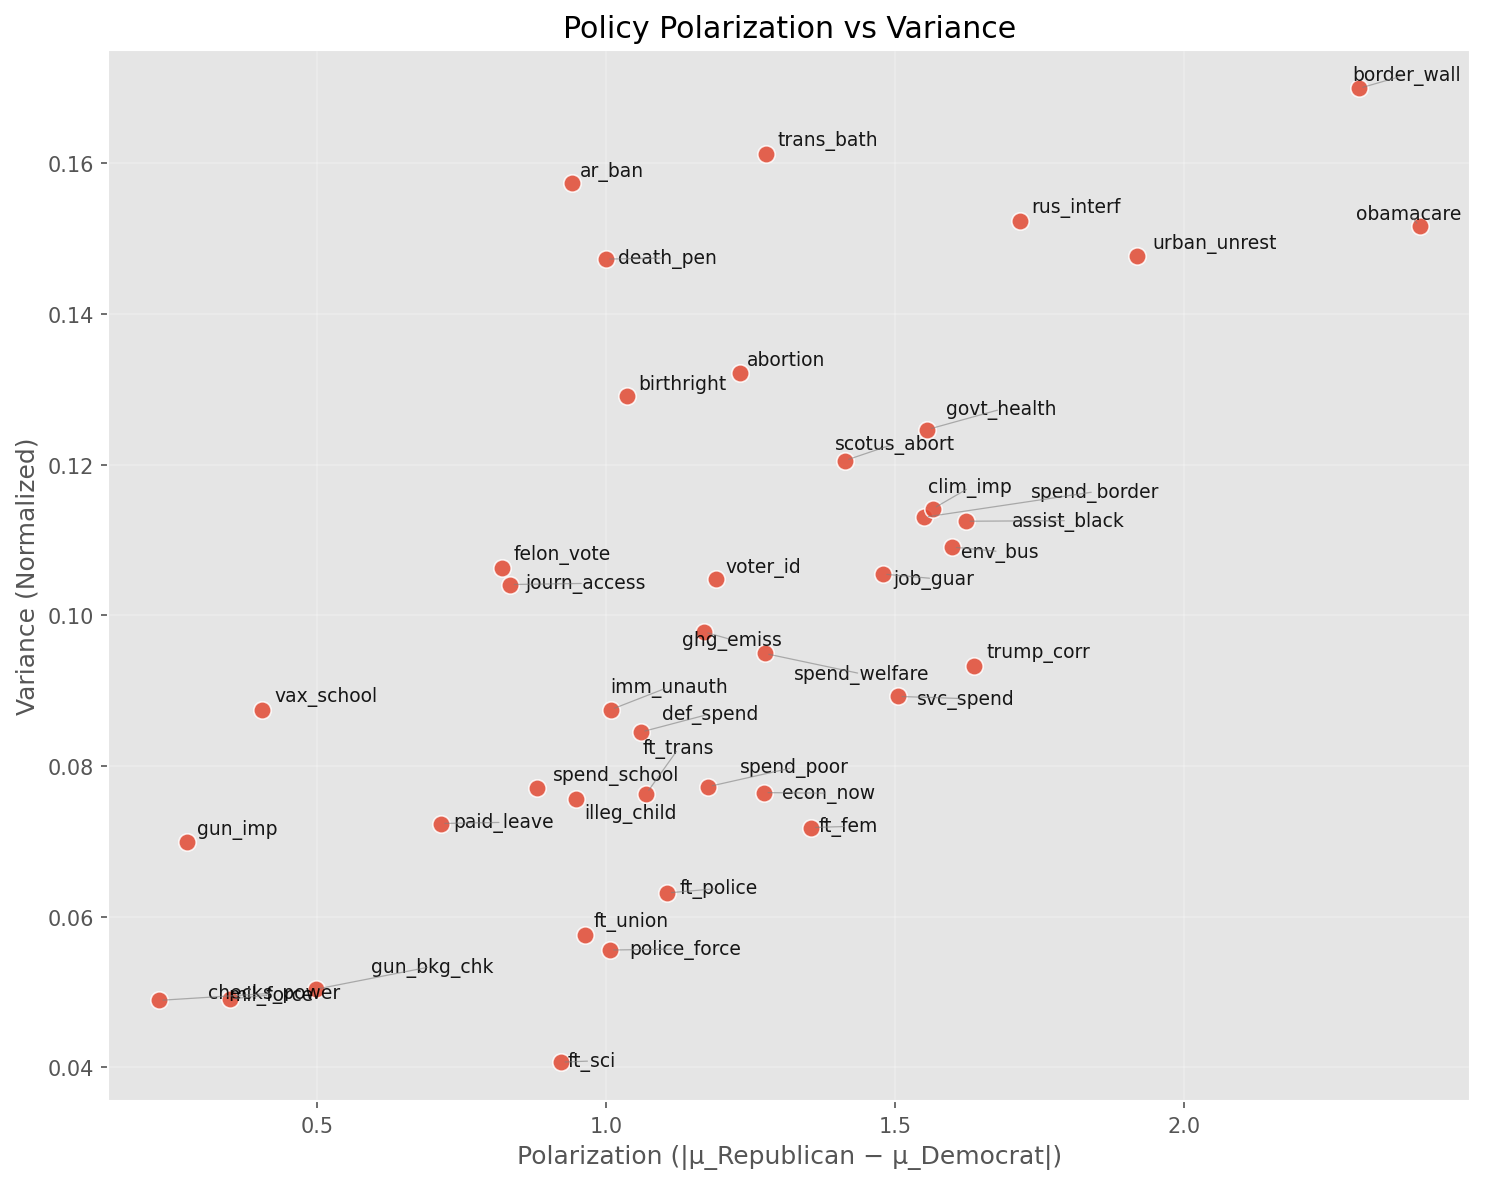

In [89]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

# Extract x and y values
x_values = [polarization[p] for p in policy_cols]
y_values = [variance[p] for p in policy_cols]

# Scatter plot
ax.scatter(
    x_values,
    y_values,
    s=70,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8,
)

# Create text objects (start exactly at the point)
texts = []
for p, x, y in zip(policy_cols, x_values, y_values):
    texts.append(
        ax.text(
            x,
            y,
            p,
            fontsize=9,
            alpha=0.9,
        )
    )

ax.set_xlabel("Polarization (|μ_Republican − μ_Democrat|)")
ax.set_ylabel("Variance (Normalized)")
ax.set_title("Policy Polarization vs Variance")
ax.grid(True, alpha=0.25)

# Add modest padding
x_pad = 0.04 * (max(x_values) - min(x_values) or 1)
y_pad = 0.04 * (max(y_values) - min(y_values) or 1)
ax.set_xlim(min(x_values) - x_pad, max(x_values) + x_pad)
ax.set_ylim(min(y_values) - y_pad, max(y_values) + y_pad)

# Strongly constrained adjustment
adjust_text(
    texts,
    x=x_values,
    y=y_values,
    ax=ax,

    # Keep labels close
    expand_points=(1.05, 1.1),
    expand_text=(1.05, 1.1),

    # Weak repulsion forces
    force_points=(0.03, 0.1),
    force_text=(0.03, 0.1),

    # Explicit attraction back to the point
    pull_points=(0.6, 0.6),
    pull_text=(0.6, 0.6),

    # Limit iterations to prevent drift
    lim=100,

    arrowprops=dict(
        arrowstyle="-",
        color="grey",
        lw=0.6,
        alpha=0.6,
    ),
)

fig.tight_layout()
plt.show()


In [ ]:
label_map = {
    # Ideology / partisanship
    "ideology_7pt": "Seven-point ideological self-placement (liberal–conservative)",
    "ideology_3pt_signed": "Collapsed ideology scale (liberal vs conservative, signed)",
    "party_id_signed": "Party identification (Democrat = −1, Republican = +1)",

    # Immigration / rights / institutions
    "imm_unauth": "Policy toward unauthorized immigrants",
    "birthright": "Support for birthright citizenship",
    "paid_leave": "Support for paid parental leave",
    "trump_corr": "Perception of Trump corruption",
    "journ_access": "Support for journalist access to government",

    # Guns / crime / courts
    "gun_bkg_chk": "Support for background checks on gun purchases",
    "illeg_child": "Treatment of children of undocumented immigrants",
    "death_pen": "Support for the death penalty",
    "abortion": "Attitudes toward legal abortion",
    "scotus_abort": "Supreme Court abortion decision attitudes",
    "ar_ban": "Support for an assault rifle ban",

    # Elections / economy
    "econ_now": "Assessment of the current national economy",
    "voter_id": "Support for voter identification laws",
    "felon_vote": "Support for voting rights for felons",

    # Health / education / spending
    "vax_school": "Support for school vaccination requirements",
    "spend_border": "Federal spending on border security",
    "spend_welfare": "Federal spending on welfare programs",
    "spend_poor": "Federal spending to aid the poor",
    "spend_school": "Federal spending on public schools",

    # Governance / social issues
    "checks_power": "Views on checks and balances among branches of government",
    "border_wall": "Support for building a border wall",
    "trans_bath": "Views on transgender bathroom access",
    "police_force": "Support for police use of force",
    "assist_black": "Government assistance to Black Americans",
    "job_guar": "Support for a government-guaranteed job",
    "govt_health": "Support for government-provided health insurance",
    "obamacare": "Attitudes toward the Affordable Care Act",

    # Spending / unrest / climate / foreign policy
    "svc_spend": "Government spending on services",
    "def_spend": "Government spending on national defense",
    "urban_unrest": "Concern about urban unrest",
    "clim_imp": "Importance of climate change",
    "rus_interf": "Concern about Russian election interference",

    # Feeling thermometers
    "ft_trans": "Feeling thermometer toward transgender people",
    "ft_union": "Feeling thermometer toward labor unions",
    "ft_fem": "Feeling thermometer toward feminists",
    "ft_sci": "Feeling thermometer toward scientists",
    "ft_police": "Feeling thermometer toward police",

    # Environment / guns / military
    "env_bus": "Environment versus business regulation tradeoff",
    "ghg_emiss": "Support for regulating greenhouse gas emissions",
    "gun_imp": "Importance of gun regulation",
    "mil_force": "Support for use of military force internationally",
}
